In [1]:
import pandas as pd 
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [80]:
df["charges"] = df["charges"].round(2)

df["predicted_charges"] = (
    df["predicted_charges"]
    .round(2)
)

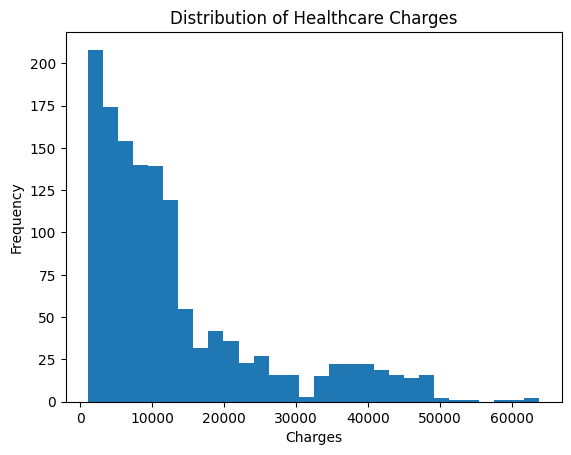

In [81]:
import matplotlib.pyplot as plt

plt.hist(df["charges"], bins=30)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Healthcare Charges")
plt.show()

In [6]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

<Figure size 1000x600 with 0 Axes>

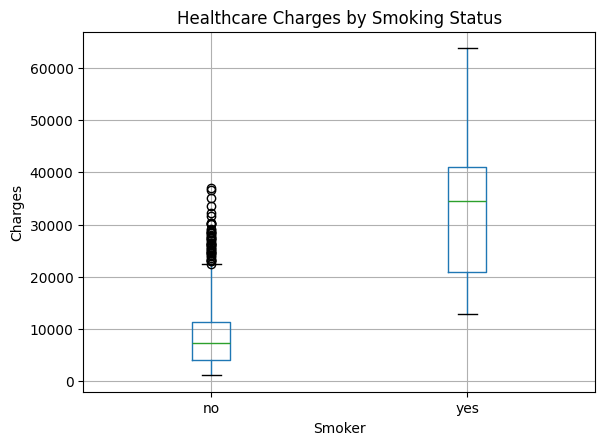

In [7]:
plt.figure(figsize=(10,6))

df.boxplot(column="charges", by="smoker")

plt.title("Healthcare Charges by Smoking Status")
plt.suptitle("")

plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

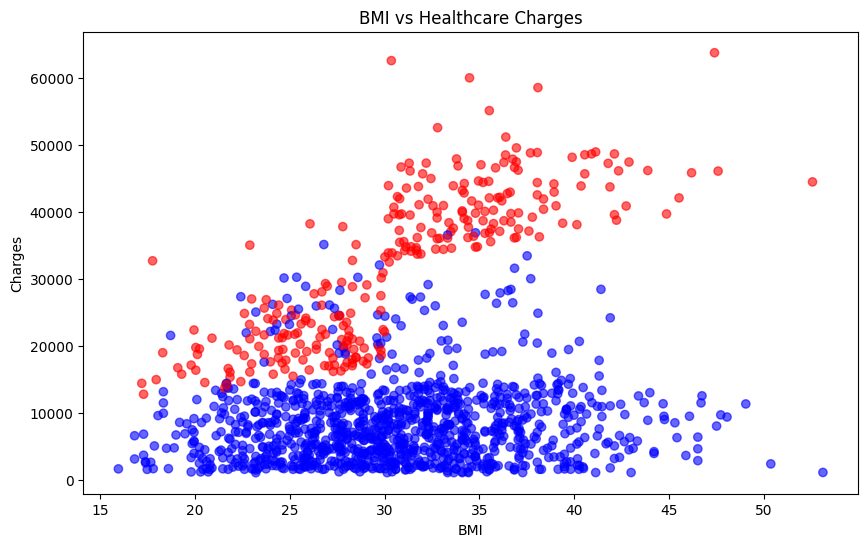

In [8]:
colors = df["smoker"].map({"yes": "red", "no": "blue"})

plt.figure(figsize=(10,6))

plt.scatter(df["bmi"], df["charges"], c=colors, alpha=0.6)

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Healthcare Charges")

plt.show()

In [9]:
df.groupby("smoker")["charges"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
smoker,,,,,
no,8434.268298,7345.40530,5993.781819,1121.8739,36910.60803
yes,32050.231832,34456.34845,11541.547176,12829.4551,63770.42801


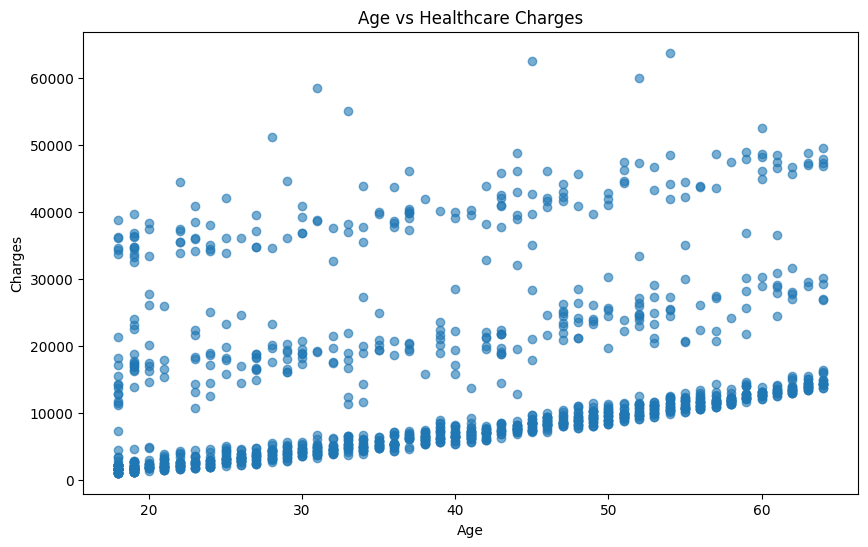

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(df["age"], df["charges"], alpha=0.6)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Healthcare Charges")

plt.show()

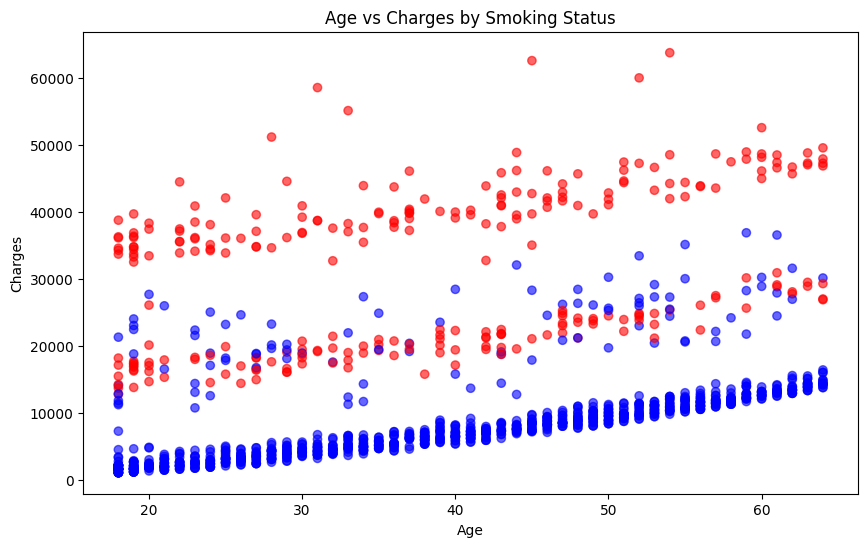

In [11]:
colors = df["smoker"].map({"yes": "red", "no": "blue"})

plt.figure(figsize=(10,6))

plt.scatter(df["age"], df["charges"], c=colors, alpha=0.6)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges by Smoking Status")

plt.show()

In [12]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [14]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

In [15]:
df.groupby("bmi_category")["charges"].mean()

bmi_category
Underweight     8657.620652
Normal         10435.440719
Overweight     10997.803881
Obese          15560.926321
Name: charges, dtype: float64

In [16]:
df.groupby("smoker")["charges"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
smoker,,,,,
no,8434.268298,7345.40530,5993.781819,1121.8739,36910.60803
yes,32050.231832,34456.34845,11541.547176,12829.4551,63770.42801


In [83]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,predicted_charges,risk_tier,bmi_group,risk_factor_group
0,19,female,27.900,0,yes,southwest,16884.92,Overweight,16336.03,Severe Risk,Medium BMI (25-30),Medium BMI / Smoker
1,18,male,33.770,1,no,southeast,1725.55,Obese,4234.53,Low Risk,High BMI (>30),High BMI / Non-Smoker
2,28,male,33.000,3,no,southeast,4449.46,Obese,6693.77,Moderate Risk,High BMI (>30),High BMI / Non-Smoker
3,33,male,22.705,0,no,northwest,21984.47,Normal,5075.80,Low Risk,Low BMI (<25),Low BMI / Non-Smoker
4,32,male,28.880,0,no,northwest,3866.86,Overweight,5032.23,Low Risk,Medium BMI (25-30),Medium BMI / Non-Smoker


In [84]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,predicted_charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,...,risk_tier_Moderate Risk,risk_tier_High Risk,risk_tier_Severe Risk,bmi_group_Medium BMI (25-30),bmi_group_High BMI (>30),risk_factor_group_High BMI / Smoker,risk_factor_group_Low BMI / Non-Smoker,risk_factor_group_Low BMI / Smoker,risk_factor_group_Medium BMI / Non-Smoker,risk_factor_group_Medium BMI / Smoker
0,19,27.900,0,16884.92,16336.03,False,True,False,False,True,...,False,False,True,True,False,False,False,False,False,True
1,18,33.770,1,1725.55,4234.53,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,28,33.000,3,4449.46,6693.77,True,False,False,True,False,...,True,False,False,False,True,False,False,False,False,False
3,33,22.705,0,21984.47,5075.80,True,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,32,28.880,0,3866.86,5032.23,True,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False


In [20]:
X = df_encoded.drop("charges", axis=1)

y = df_encoded["charges"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MAE: 4316.35706994627
RMSE: 5873.4207298003685
R^2: 0.7777948280944462


In [53]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False).reset_index(drop=True)

,Feature,Coefficient
0,smoker_yes,23667.145565
1,bmi_category_Obese,7270.223735
2,bmi_category_Overweight,3270.351784
3,bmi_category_Normal,2603.291955
4,children,414.897342
5,age,256.683920
6,sex_male,-13.754877


In [46]:
import statsmodels.api as sm

X_glm = sm.add_constant(X).astype(float)
y_glm = y.astype(float)

gamma_model = sm.GLM(
    y,
    X_glm,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
)


gamma_results = gamma_model.fit()

print(gamma_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                 1338
Model:                            GLM   Df Residuals:                     1330
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                         0.46319
Method:                          IRLS   Log-Likelihood:                -13307.
Date:                Wed, 27 May 2026   Deviance:                       340.01
Time:                        20:55:27   Pearson chi2:                     616.
No. Iterations:                    18   Pseudo R-squ. (CS):             0.6851
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [71]:
import numpy as np
import pandas as pd

glm_effects = pd.DataFrame({
    "Feature": gamma_results.params.index,
    "Coefficient": gamma_results.params.values,
    "Multiplier": np.exp(gamma_results.params.values),
    "Percent_Change": (np.exp(gamma_results.params.values) - 1) * 100,
    "P_Value": gamma_results.pvalues.values
})

glm_effects.sort_values(by="Multiplier", ascending=False).reset_index(drop=True)

,Feature,Coefficient,Multiplier,Percent_Change,P_Value
0,const,7.410453,1653.174438,165217.443759,0.000000e+00
1,smoker_yes,1.491901,4.445538,344.553757,4.194080e-228
2,bmi_category_Obese,0.397233,1.487703,48.770323,8.610285e-03
3,bmi_category_Overweight,0.254771,1.290166,29.016573,9.548383e-02
4,bmi_category_Normal,0.234761,1.264607,26.460674,1.309384e-01
5,children,0.085793,1.089581,8.958072,2.869606e-08
6,age,0.028632,1.029046,2.904565,4.605281e-102
7,sex_male,-0.057823,0.943817,-5.618339,1.219992e-01


In [ ]:
glm_predictions = gamma_results.predict(X_glm)

In [76]:
comparison = pd.DataFrame({
    "Actual_Charges": y_glm,
    "Predicted_Charges": glm_predictions
})

comparison["Percent_Difference"] = (
    abs(
        comparison["Actual_Charges"]
        - comparison["Predicted_Charges"]
    )
    / comparison["Actual_Charges"]
) * 100

comparison["Percent_Difference"] = (
    comparison["Percent_Difference"]
    .round(2)
    .astype(str) + "%"
)

comparison.head(10)

,Actual_Charges,Predicted_Charges,Percent_Difference
0,16884.92400,16336.033744,3.25%
1,1725.55230,4234.533047,145.4%
2,4449.46200,6693.769318,50.44%
3,21984.47061,5075.804640,76.91%
4,3866.85520,5032.227514,30.14%
5,3756.62160,5181.291342,37.92%
6,8240.58960,10002.022372,21.38%
7,7281.50560,7958.369128,9.3%
8,6406.41070,6893.698490,7.61%
9,28923.13692,11886.187124,58.9%


In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

glm_mae = mean_absolute_error(y_glm, glm_predictions)
glm_rmse = np.sqrt(mean_squared_error(y_glm, glm_predictions))
glm_r2 = r2_score(y_glm, glm_predictions)

print("Gamma GLM MAE:", glm_mae)
print("Gamma GLM RMSE:", glm_rmse)
print("Gamma GLM R^2:", glm_r2)

Gamma GLM MAE: 4360.8480630682825
Gamma GLM RMSE: 7610.917249906238
Gamma GLM R^2: 0.6047156555661808


In [77]:
df["predicted_charges"] = glm_predictions

df["risk_tier"] = pd.qcut(
    df["predicted_charges"],
    q=4,
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Severe Risk"
    ]
)

In [56]:
df["risk_tier"].value_counts()

risk_tier
Low Risk         338
Severe Risk      335
High Risk        334
Moderate Risk    331
Name: count, dtype: int64

In [57]:
df.groupby("risk_tier")["charges"].mean()

risk_tier
Low Risk          4308.426475
Moderate Risk     7531.215324
High Risk        12079.940687
Severe Risk      29170.281733
Name: charges, dtype: float64

In [58]:
pd.crosstab(
    df["risk_tier"],
    df["smoker"],
    normalize="index"
) * 100

smoker,no,yes
risk_tier,,
Low Risk,100.000000,0.000000
Moderate Risk,100.000000,0.000000
High Risk,99.700599,0.299401
Severe Risk,18.507463,81.492537


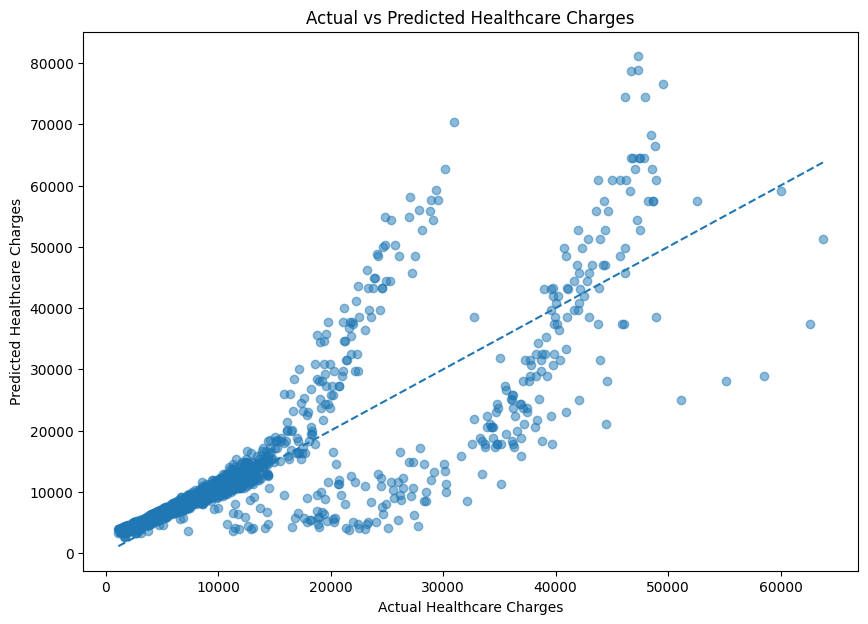

In [78]:
plt.figure(figsize=(10,7))

plt.scatter(
    y_glm,
    glm_predictions,
    alpha=0.5
)

plt.plot(
    [y_glm.min(), y_glm.max()],
    [y_glm.min(), y_glm.max()],
    linestyle="--"
)

plt.xlabel("Actual Healthcare Charges")
plt.ylabel("Predicted Healthcare Charges")

plt.title("Actual vs Predicted Healthcare Charges")

plt.savefig(
    "../visuals/actual_vs_predicted_charges.png",
    bbox_inches="tight"
)

plt.show()